
Researching how the ATR can be used in trading

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from datetime import datetime
from data_agg.data_service import DataService
from lab.atr_study import AverageTrueRange, AtrType

In [3]:
start = datetime(2026, 1, 1)
end = datetime(2026, 1, 30)
ds = DataService()
df = ds.get_candles("MNQ", "1min", start, end)

In [4]:
sample = df.head(100)
atr = AverageTrueRange(period=14, type= AtrType.WLDR, candles=df)
atr = atr.get_rolling_atr()
atr


,window_start,atr
0,2026-01-08 11:38:00,0.00
1,2026-01-08 11:39:00,0.00
2,2026-01-08 11:40:00,0.00
3,2026-01-08 11:41:00,0.00
4,2026-01-08 11:42:00,0.00
...,...,...
21138,2026-01-29 23:56:00,12.21
21139,2026-01-29 23:57:00,12.14
21140,2026-01-29 23:58:00,12.34
21141,2026-01-29 23:59:00,12.53


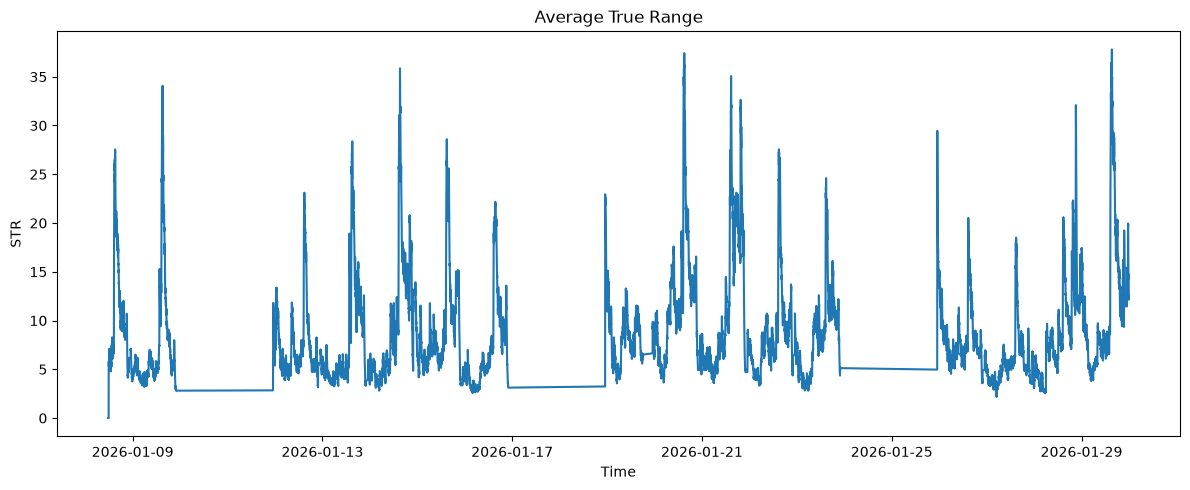

In [5]:
plt.figure(figsize=(12,5))
plt.plot(atr['window_start'], atr['atr'])
plt.title('Average True Range')
plt.xlabel('Time')
plt.ylabel('STR')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(atr['atr'], height=15, distance=5)

peak_times = atr['window_start'].iloc[peaks]
peak_values = atr['atr'].iloc[peaks]

peak_df = pd.DataFrame({
    'time': peak_times.values,
    'atr': peak_values.values
})
